In [1]:
pip install xarray netCDF4 numpy matplotlib

  Using cached xarray-2026.2.0-py3-none-any.whl.metadata (12 kB)
  Using cached netcdf4-1.7.4-cp311-abi3-macosx_14_0_arm64.whl.metadata (2.1 kB)
  Using cached cftime-1.6.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.7 kB)
Using cached xarray-2026.2.0-py3-none-any.whl (1.4 MB)
Using cached netcdf4-1.7.4-cp311-abi3-macosx_14_0_arm64.whl (22.8 MB)
Using cached cftime-1.6.5-cp313-cp313-macosx_11_0_arm64.whl (484 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [xarray]2m2/3 [xarray]]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import xarray as xr

ds = xr.open_dataset("/Users/sumitkumar776693/Desktop/IGNISHIA/methane-guardian-ai/preprocess/dataset/S5P_OFFL_L2__CH4____20251101T151515_20251101T165645_41729_03_020800_20251103T073000 (1).nc", group="PRODUCT")
print(ds)

<xarray.Dataset> Size: 25MB
Dimensions:                                        (time: 1, scanline: 4172,
                                                    ground_pixel: 215,
                                                    corner: 4, layer: 12,
                                                    level: 13)
Coordinates:
  * time                                           (time) datetime64[ns] 8B 2...
  * scanline                                       (scanline) float64 33kB 0....
  * ground_pixel                                   (ground_pixel) float64 2kB ...
    latitude                                       (time, scanline, ground_pixel) float32 4MB ...
    longitude                                      (time, scanline, ground_pixel) float32 4MB ...
  * corner                                         (corner) float64 32B 0.0 ....
  * layer                                          (layer) float64 96B 0.0 .....
  * level                                          (level) float64 104B 

In [6]:
ch4 = ds['methane_mixing_ratio_bias_corrected']  # sometimes this name
qa = ds['qa_value']
lat = ds['latitude']
lon = ds['longitude']

In [7]:
print(ds.data_vars)

Data variables:
    delta_time                                     (time, scanline) datetime64[ns] 33kB ...
    time_utc                                       (time, scanline) object 33kB ...
    qa_value                                       (time, scanline, ground_pixel) float32 4MB ...
    methane_mixing_ratio                           (time, scanline, ground_pixel) float32 4MB ...
    methane_mixing_ratio_precision                 (time, scanline, ground_pixel) float32 4MB ...
    methane_mixing_ratio_bias_corrected            (time, scanline, ground_pixel) float32 4MB ...
    methane_mixing_ratio_bias_corrected_destriped  (time, scanline, ground_pixel) float32 4MB ...


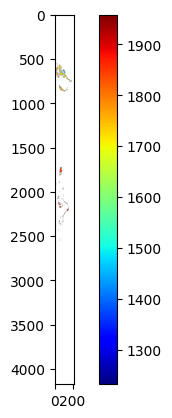

In [8]:
import matplotlib.pyplot as plt

plt.imshow(ch4[0], cmap='jet')
plt.colorbar()
plt.show()

In [10]:
ch4 = ds['methane_mixing_ratio_bias_corrected']
qa = ds['qa_value']

In [11]:
import numpy as np

ch4_clean = np.where(qa > 0.5, ch4, np.nan)

In [12]:
ch4_img = ch4_clean[0]

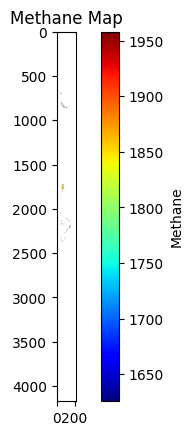

In [13]:
import matplotlib.pyplot as plt

plt.imshow(ch4_img, cmap='jet')
plt.colorbar(label="Methane")
plt.title("Methane Map")
plt.show()

In [14]:
plume_mask = ch4_img > 1800

In [15]:
input_data = np.expand_dims(ch4_img, axis=-1)

In [19]:
import torch
from torch.utils.data import Dataset
import xarray as xr
import numpy as np

class MethaneDataset(Dataset):
    def __init__(self, file_list):
        self.files = file_list

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        ds = xr.open_dataset(self.files[idx], group="PRODUCT")

        ch4 = ds['methane_mixing_ratio_bias_corrected'].values
        qa = ds['qa_value'].values

        # Cleaning
        ch4 = np.where(qa > 0.5, ch4, 0)

        # Take first time slice
        ch4 = ch4[0]

        # Normalize
        ch4 = (ch4 - np.nanmin(ch4)) / (np.nanmax(ch4) - np.nanmin(ch4) + 1e-6)

        # Label (pseudo)
        mask = (ch4 > 0.6).astype(np.float32)

        # Add channel dim
        ch4 = np.expand_dims(ch4, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(ch4, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [20]:
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = block(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = block(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = block(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        d1 = self.up1(e3)
        d1 = torch.cat([d1, e2], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        return torch.sigmoid(self.out(d2))

In [21]:
from torch.utils.data import DataLoader

dataset = MethaneDataset(file_list)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

model = UNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

for epoch in range(5):
    for x, y in loader:
        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} Loss: {loss.item()}")

NameError: name 'file_list' is not defined

In [ ]:
import matplotlib.pyplot as plt

x, y = dataset[0]
pred = model(x.unsqueeze(0)).detach().numpy()[0,0]

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(x[0], cmap='jet')

plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(y[0])

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred)

plt.show()